In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to sys.path
current_path = Path.cwd()
project_root = current_path.parents[1]  # Assuming this file is in VisualScripts/DataAnalysis/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project Root: {project_root}")

# Import project modules
try:
    from RawDataProcessing.ParseLogFile import load_config, parse_logfile
except ImportError:
    # Fallback if running from a different directory structure
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))
    from RawDataProcessing.ParseLogFile import load_config, parse_logfile

# Constants for Disk Galaxy Eddington calculation (from ParseLogFile.ll_dg)
G = 112
m_p = 3.365e-65
eta = 0.1
c = 3.07e5
sigma_t = 6.99e-68

def calculate_eddington_limit(mbh):
    """Calculate Eddington accretion rate for a given BH mass."""
    return (4 * np.pi * G * mbh * m_p) / (eta * c * sigma_t)


Project Root: d:\PersonFiles\Codes\Project\MACNet v1


Processing Group Type: elliptical_galaxy
  - Galaxy: elliptical_galaxy_fiducial


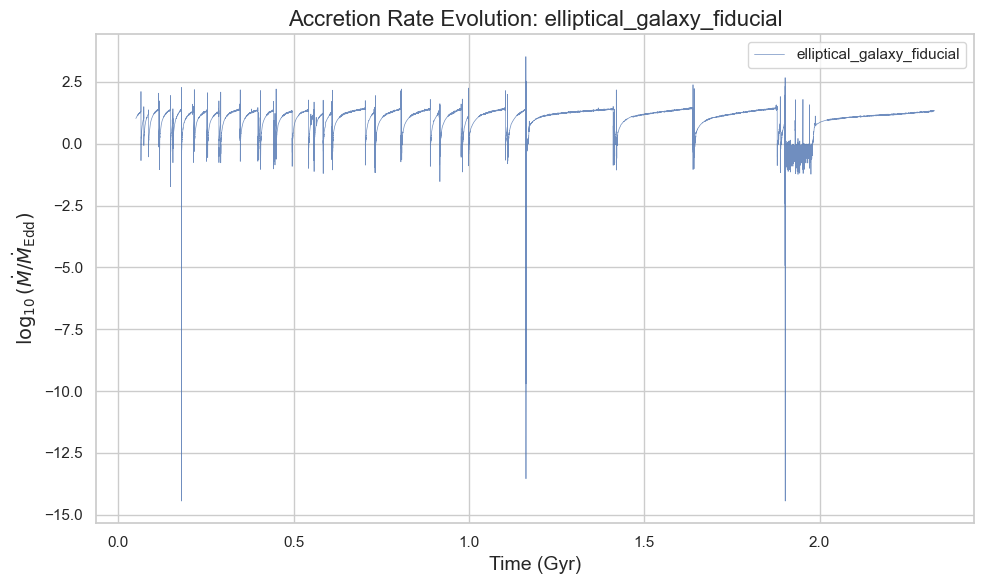

  - Galaxy: elliptical_galaxy_0dot1


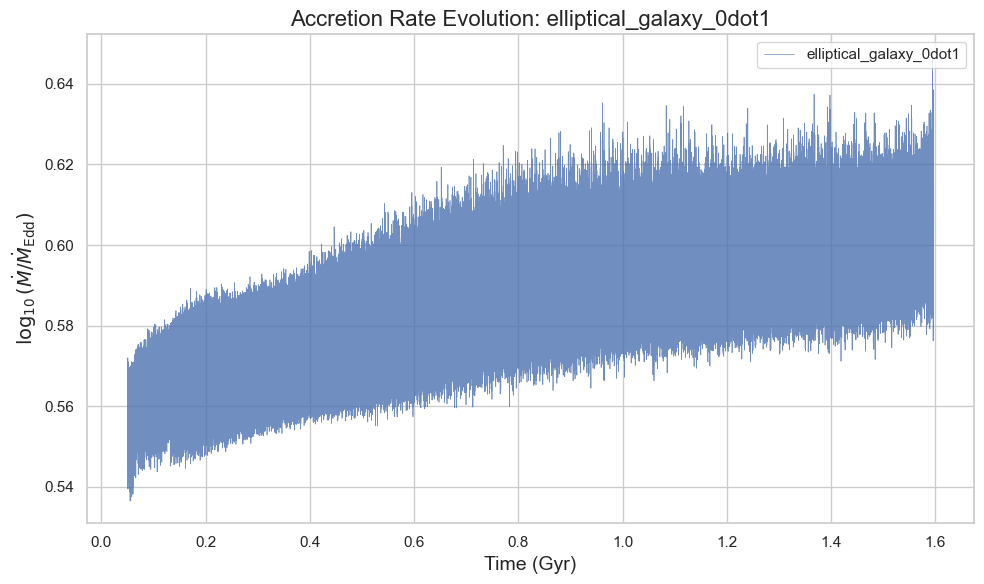

  - Galaxy: elliptical_galaxy_pgc


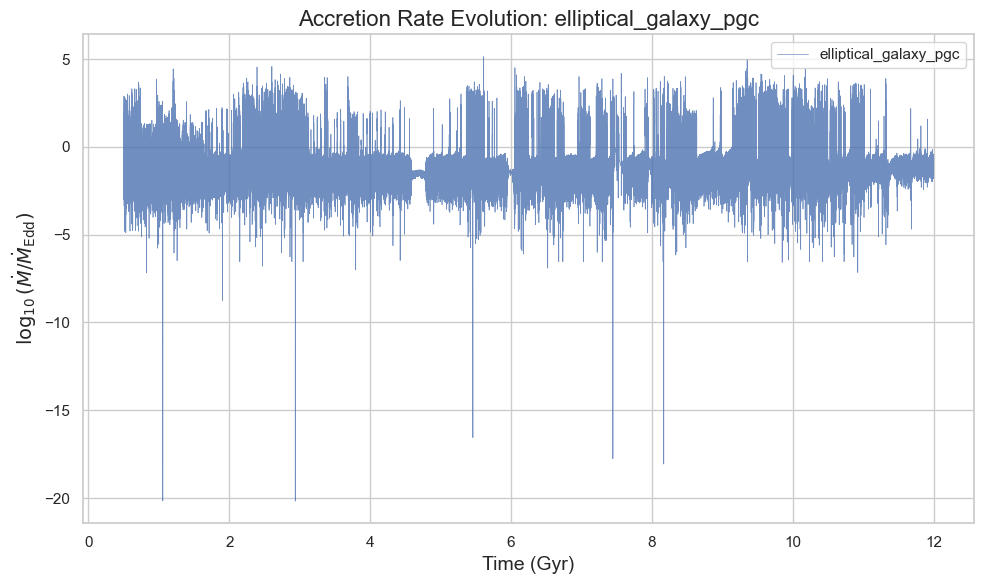

Processing Group Type: disk_galaxy
  - Galaxy: disk_galaxy_fiducial


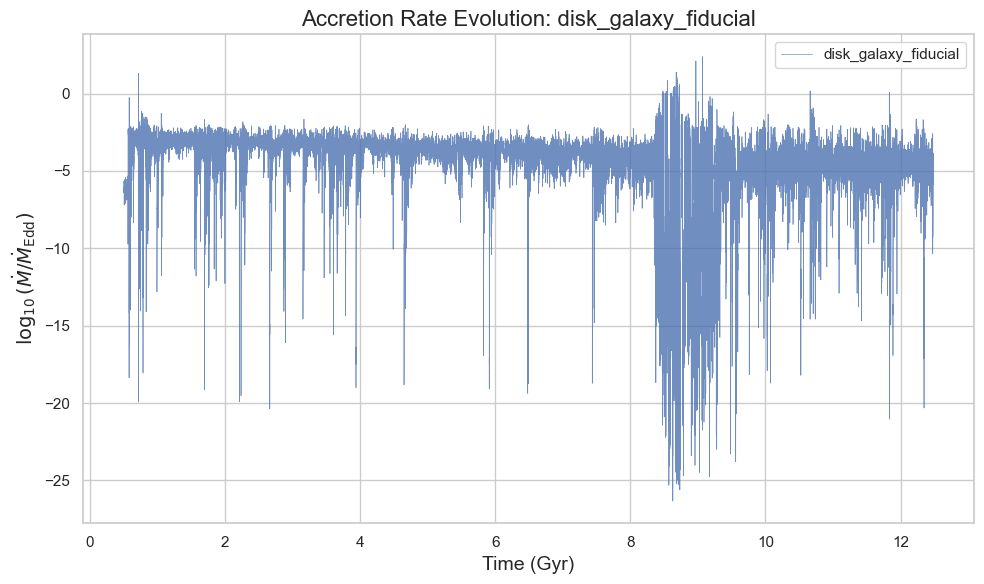

  - Galaxy: disk_galaxy_supplement


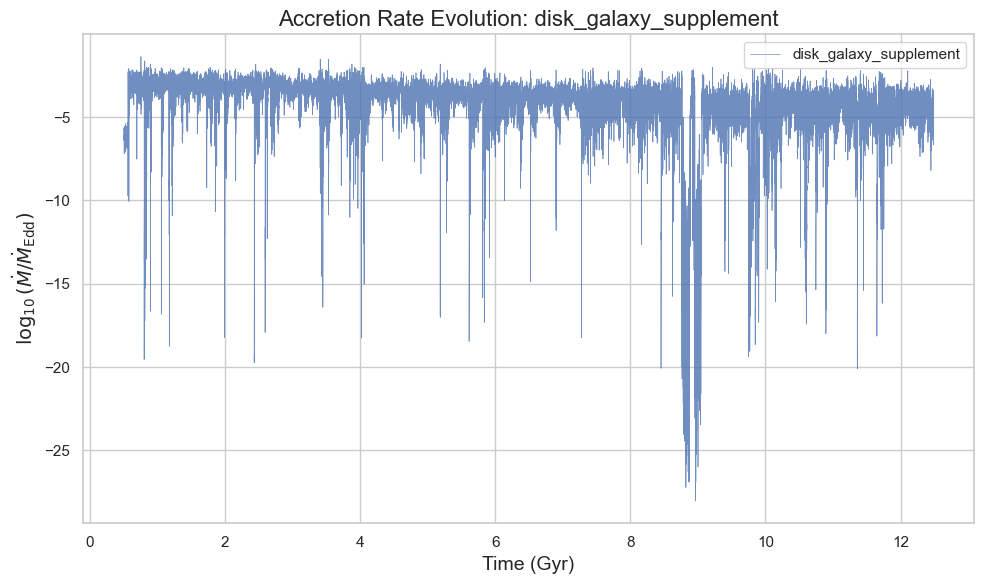

  - Galaxy: disk_galaxy_fiducial_4


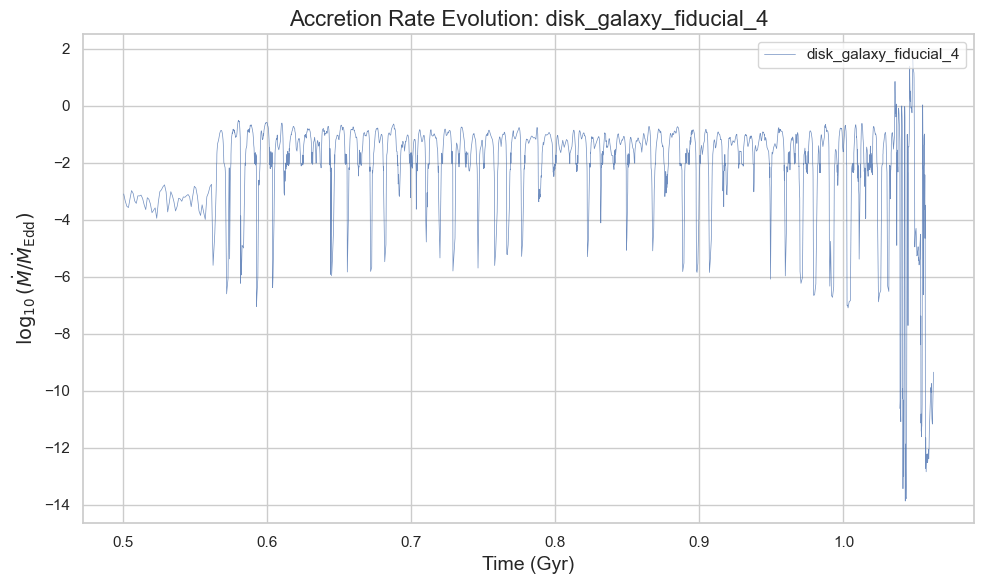

  - Galaxy: disk_galaxy_fiducial_7


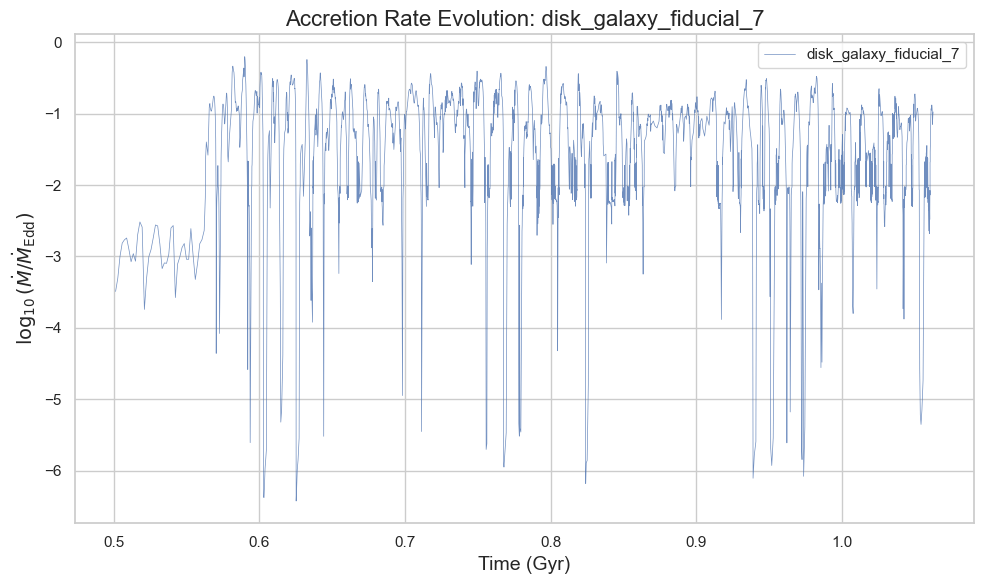

  - Galaxy: disk_galaxy_fiducial_10


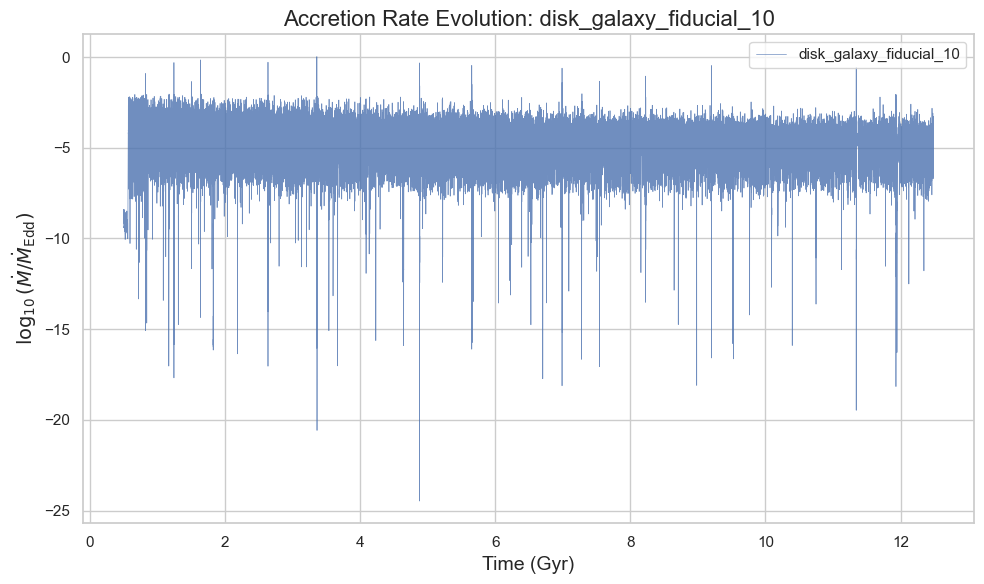

  - Galaxy: disk_galaxy_low


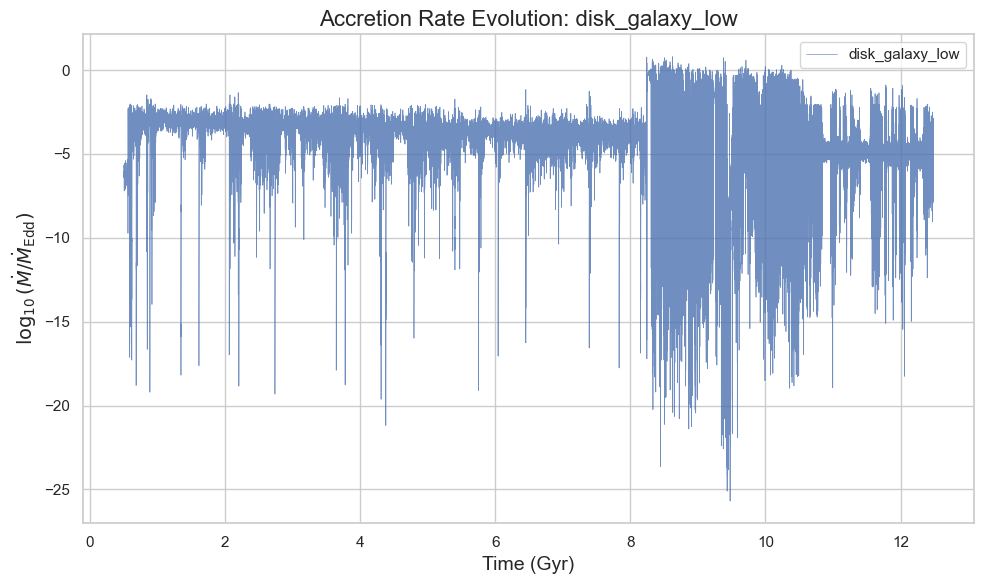

In [2]:
# Load Configurations
configs = load_config(os.path.join(project_root, ".config"))
raw_data_base = configs["BaseConfig"]["raw_data_dir"]
data_dir = configs["BaseConfig"]["data_dir"]
os.makedirs(data_dir, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")

# Iterate over all defined galaxy groups
for gal_type, gal_group in configs["RawDataConfig"].items():
    print(f"Processing Group Type: {gal_type}")
    
    # Get column names for this galaxy type
    if gal_type in configs["HdfraConfig"]:
         col_names = configs["HdfraConfig"][gal_type]["colnames"]
    else:
        print(f"Warning: No column config found for {gal_type}")
        continue
    
    for gal_nickname, gal_config in gal_group.items():
        gal_name = f"{gal_type}_{gal_nickname}"
        print(f"  - Galaxy: {gal_name}")
        
        # Define paths
        raw_log_path = os.path.join(raw_data_base, gal_config["folder_name"], gal_config["log_file"])
        parquet_path = os.path.join(data_dir, f"{gal_name}.parquet")
        
        # Parse/Load Data
        try:
            # This handles loading parquet if exists, or parsing raw log if not
            if not os.path.exists(raw_log_path) and not os.path.exists(parquet_path):
                 print(f"    [Skip] Source log not found: {raw_log_path}")
                 continue

            df = parse_logfile(
                path=raw_log_path, 
                colnames=col_names, 
                save_path=parquet_path, 
                force_parse=False # Set to True to force re-parsing
            )
        except Exception as e:
            print(f"    [Error] Could not load data for {gal_name}: {e}")
            continue
            
        # Process Data for Plotting
        try:
            time = df["time"]
            ratio = None
            
            if "elliptical" in gal_type:
                # For Elliptical: mdot_ratio is strictly mdot / mdot_edd
                # Check directly if column exists
                if "mdot_ratio" in df.columns:
                    ratio = df["mdot_ratio"]
                else:
                    # Fallback if needed
                    ratio = df["mdot"] / df["mdot_edd"]
                    
            elif "disk" in gal_type:
                # For Disk: Calculate Eddington Rate first
                # mdot_bh is the accretion rate
                mbh = df["mbh"]
                mdot_bh = df["mdot_bh"]
                mdot_edd = calculate_eddington_limit(mbh)
                ratio = mdot_bh / mdot_edd
            
            if ratio is not None:
                # Time Truncation Logic
                # Default start time is 0.5 Gyr
                start_time = 0.5
                # Specific start time for selected galaxies
                # Matching user request "elliptical_galaxy_0dot_1" (assuming 0dot1 in config) and "elliptical_galaxy_fiducial"
                if gal_name in ["elliptical_galaxy_0dot1", "elliptical_galaxy_fiducial"]:
                    start_time = 0.05
                
                # Filter out non-positive ratios to avoid log errors AND apply time truncation
                valid_mask = (ratio > 0) & (time >= start_time)
                
                if valid_mask.sum() == 0:
                    print(f"    [Warning] No positive accretion/eddington ratios found or all filtered out by time >= {start_time}.")
                    continue
                
                log_ratio = np.log10(ratio[valid_mask])
                valid_time = time[valid_mask]
                
                # Plot for EACH galaxy
                plt.figure(figsize=(10, 6))
                plt.plot(valid_time, log_ratio, label=gal_name, color='b', alpha=0.8, linewidth=0.5)
                
                plt.xlabel("Time (Gyr)", fontsize=14)
                plt.ylabel(r"$\log_{10}(\dot{M} / \dot{M}_{\rm Edd})$", fontsize=14)
                plt.title(f"Accretion Rate Evolution: {gal_name}", fontsize=16)
                plt.legend(loc='upper right')
                plt.tight_layout()
                plt.show()
                
        except KeyError as e:
            print(f"    [Error] Missing column for calculation: {e}")



Starting HDF5 Data Visualization (Coarse Grid)

Found 9 dataset folders.
Loading HDF5 data for: disk_galaxy_fiducial ...


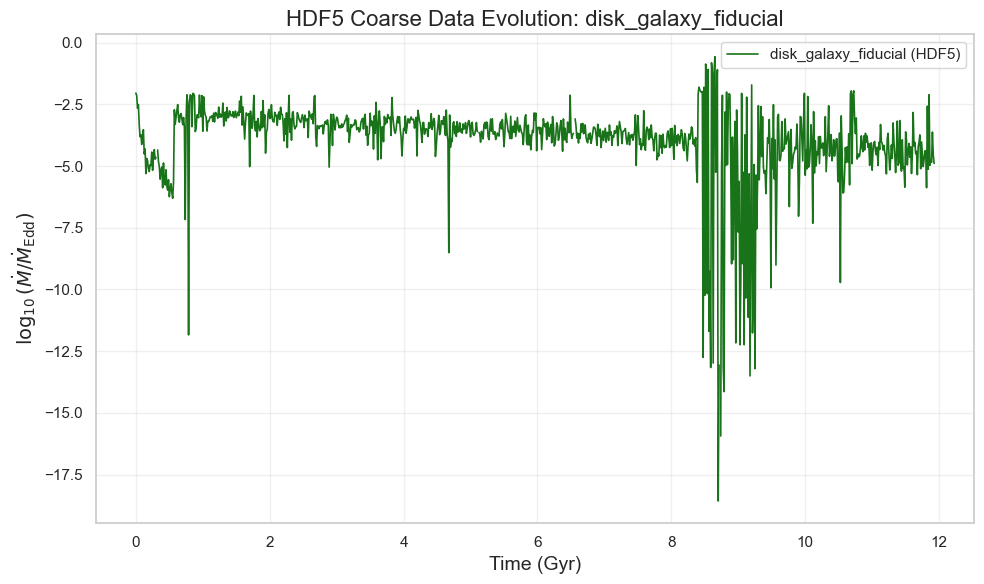

  [Success] Plotted 955 points.
Loading HDF5 data for: disk_galaxy_fiducial_10 ...


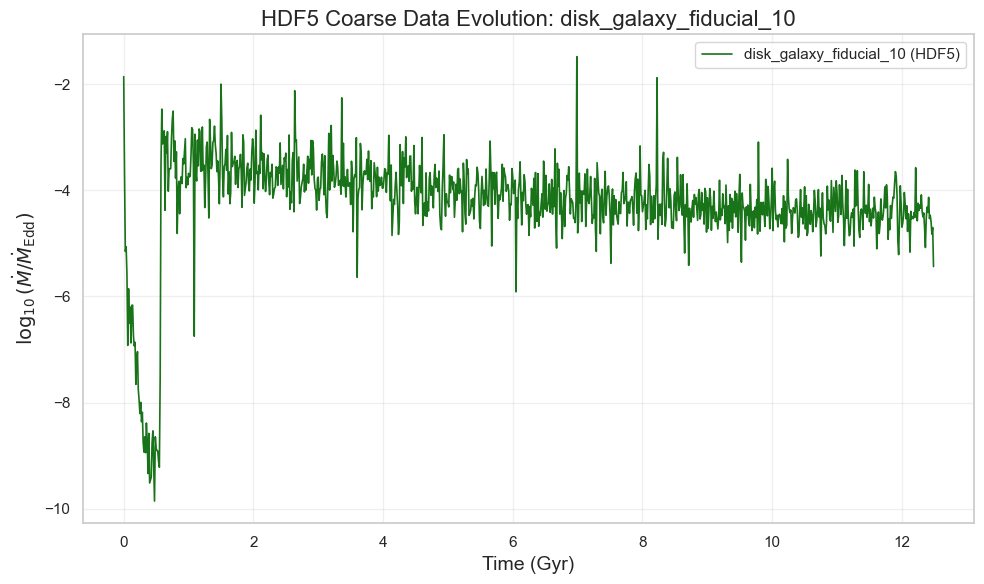

  [Success] Plotted 1000 points.
Loading HDF5 data for: disk_galaxy_fiducial_4 ...


d:\PersonFiles\Codes\Project\MACNet v1\RawDataProcessing\GalaxyData.py:516: RuntimeWarning: divide by zero encountered in log10
  return np.log10(mdot_macer / mdot_edd)


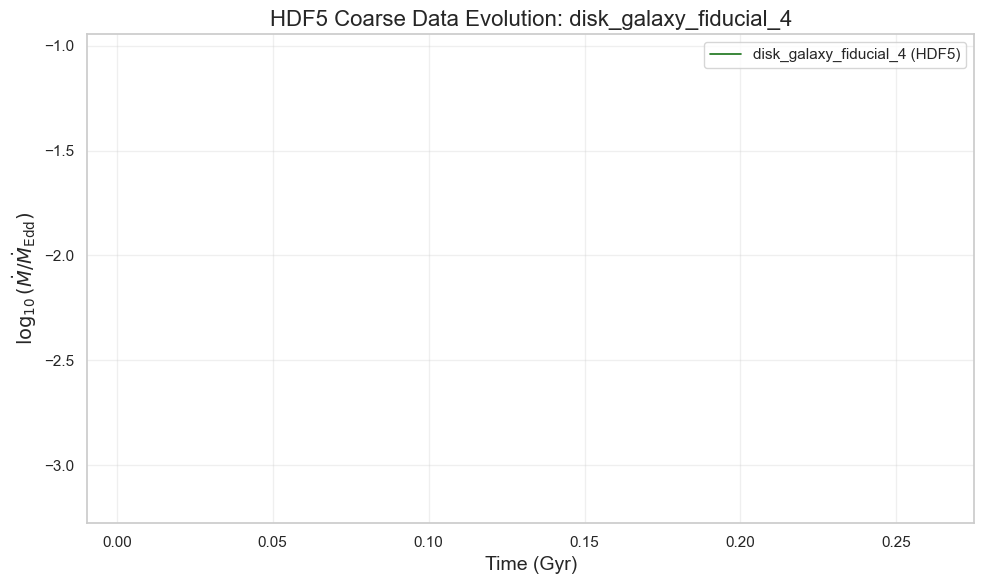

  [Success] Plotted 531 points.
Loading HDF5 data for: disk_galaxy_fiducial_7 ...


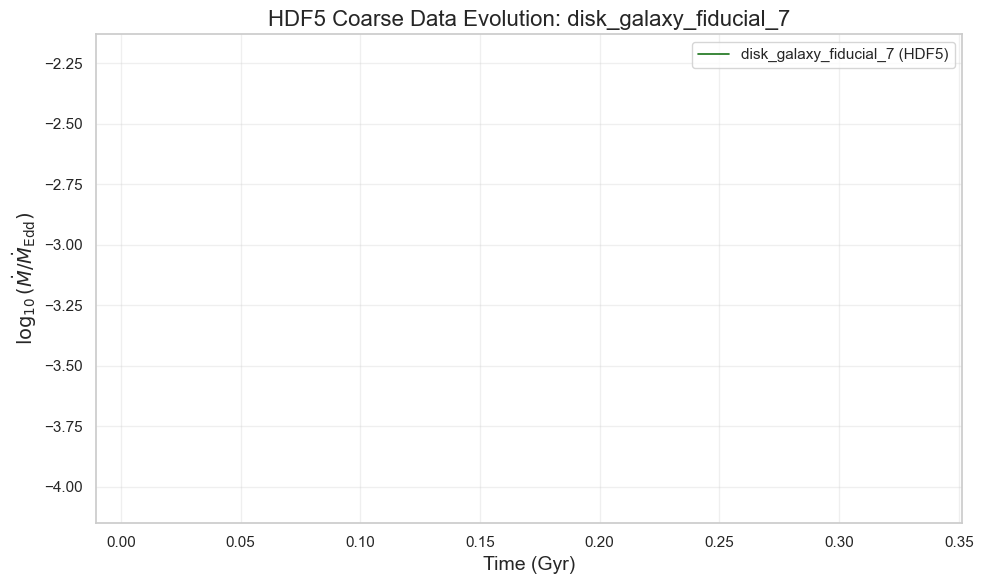

  [Success] Plotted 690 points.
Loading HDF5 data for: disk_galaxy_low ...


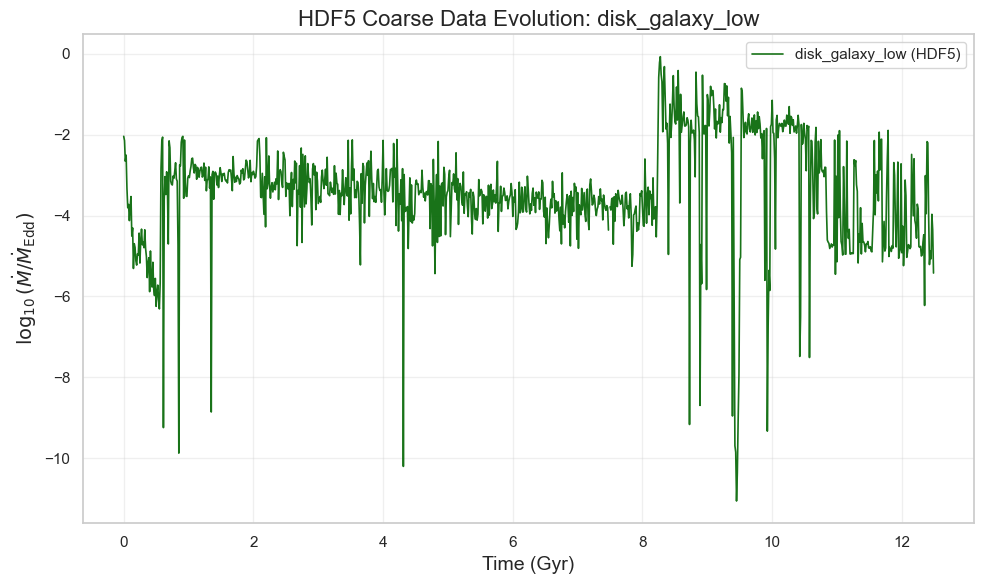

  [Success] Plotted 1000 points.
Loading HDF5 data for: disk_galaxy_supplement ...


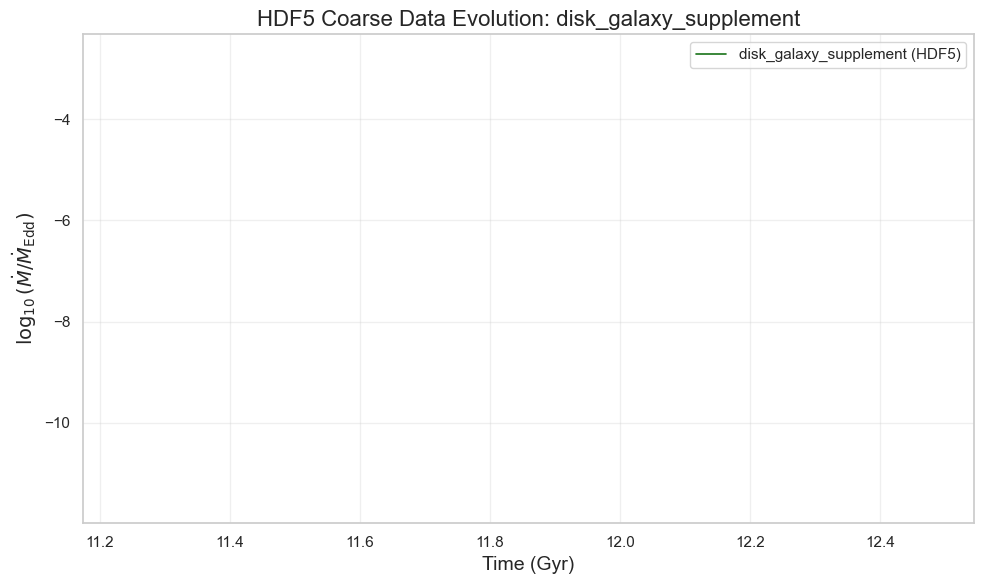

  [Success] Plotted 1000 points.
Loading HDF5 data for: elliptical_galaxy_0dot1 ...


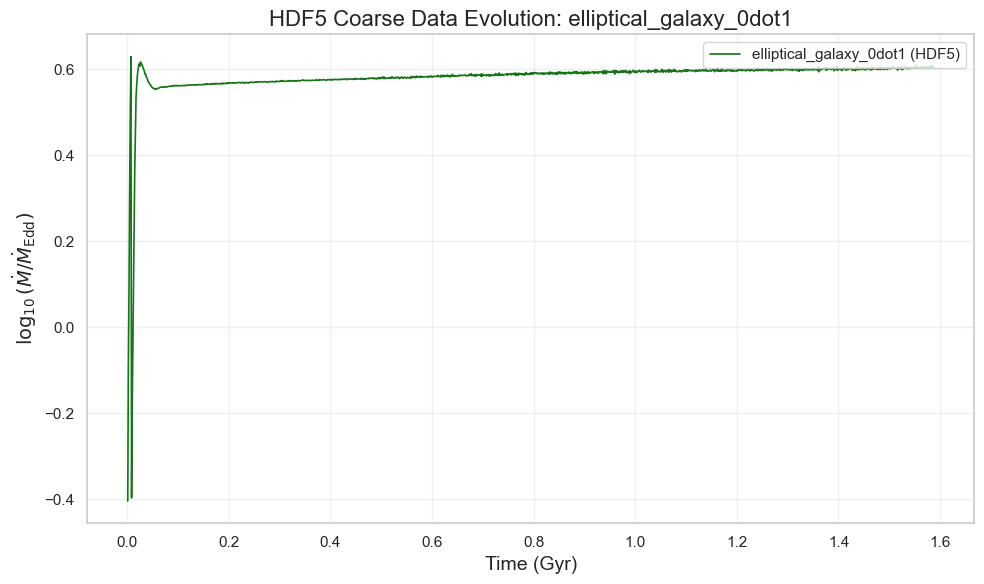

  [Success] Plotted 1271 points.
Loading HDF5 data for: elliptical_galaxy_fiducial ...


d:\PersonFiles\Codes\Project\MACNet v1\RawDataProcessing\GalaxyData.py:516: RuntimeWarning: invalid value encountered in divide
  return np.log10(mdot_macer / mdot_edd)


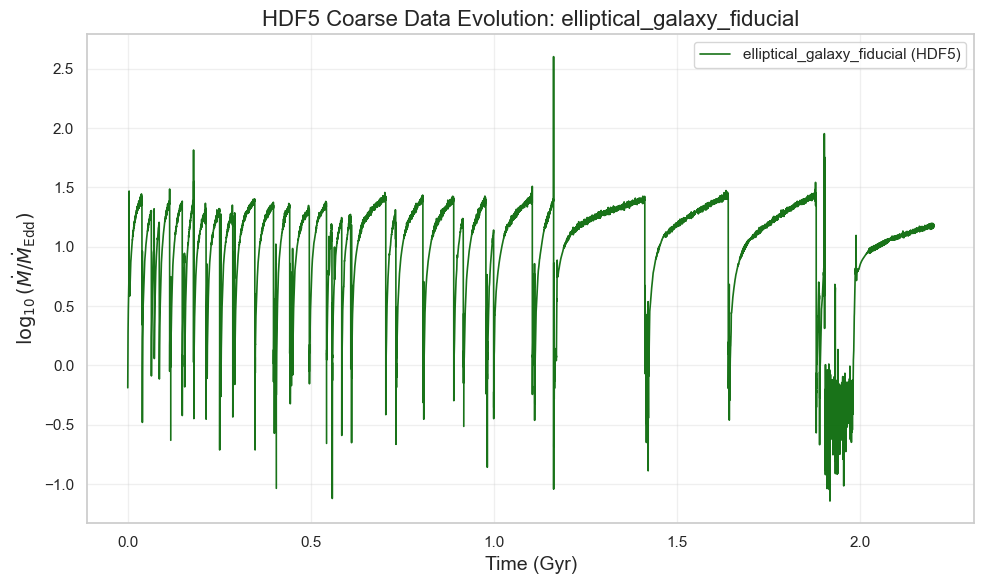

  [Success] Plotted 22000 points.
Loading HDF5 data for: elliptical_galaxy_pgc ...


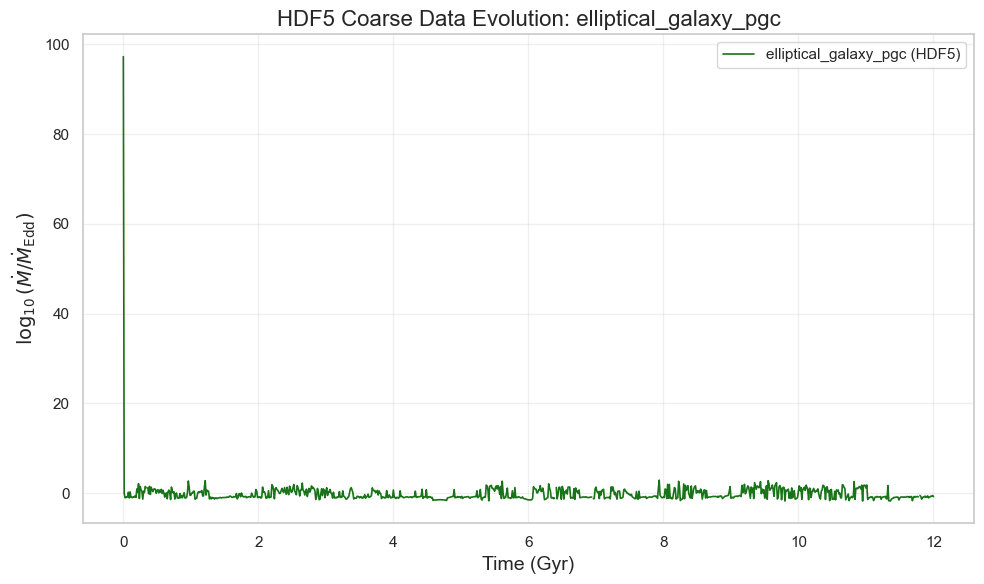

  [Success] Plotted 961 points.


In [3]:
# ==========================================
# Part 2: Visualization from HDF5 Data (Coarse Grid)
# ==========================================
# This section reads the processed .h5 files directly from the Data/ directories
# ensuring validation against the actual grid data used in training.

print("\n" + "="*50)
print("Starting HDF5 Data Visualization (Coarse Grid)")
print("="*50 + "\n")

try:
    from RawDataProcessing.GalaxyData import GalDataSet
    
    # scan for 'coarse' folders in Data directory
    data_path = Path(data_dir)
    coarse_folders = sorted(list(data_path.glob("*/coarse"))) # Sorted for consistent order
    
    if not coarse_folders:
        print(f"[Info] No 'coarse' data folders found in {data_path}")
    else:
        print(f"Found {len(coarse_folders)} dataset folders.")

    for folder in coarse_folders:
        galaxy_name = folder.parent.name
        print(f"Loading HDF5 data for: {galaxy_name} ...")
        
        try:
            # Load data using GalDataSet
            # GalDataSet loads all files in the folder. This might take a moment.
            ds = GalDataSet()
            ds.load_data((str(folder), 0)) # Group ID 0 is dummy
            
            if len(ds) == 0:
                print(f"  [Warning] Dataset is empty.")
                continue
                
            # Extract Raw Arrays
            # We access raw lists and convert to numpy for sorting/filtering
            times = np.array(ds.raw_data['time'])
                
            # Log Ratio
            y_vals = np.array(ds.y)
            t_vals = times
            
            # Plot
            plt.figure(figsize=(10, 6))
            plt.plot(t_vals, y_vals, label=f"{galaxy_name} (HDF5)", color='darkgreen', alpha=0.9, linewidth=1.2)
            
            plt.xlabel("Time (Gyr)", fontsize=14)
            plt.ylabel(r"$\log_{10}(\dot{M} / \dot{M}_{\rm Edd})$", fontsize=14)
            plt.title(f"HDF5 Coarse Data Evolution: {galaxy_name}", fontsize=16)
            plt.legend(loc='upper right')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print(f"  [Success] Plotted {len(t_vals)} points.")
            
        except ImportError:
             print("  [Error] RawDataProcessing module not found/installed correctly.")
             break
        except Exception as e:
            print(f"  [Error] Failed to process {galaxy_name}: {e}")

except Exception as e:
    print(f"An error occurred during HDF5 processing: {e}")



Starting Time Step (dt) Evolution Analysis (.parquet)

Processing Group Type: elliptical_galaxy
  - Galaxy: elliptical_galaxy_fiducial


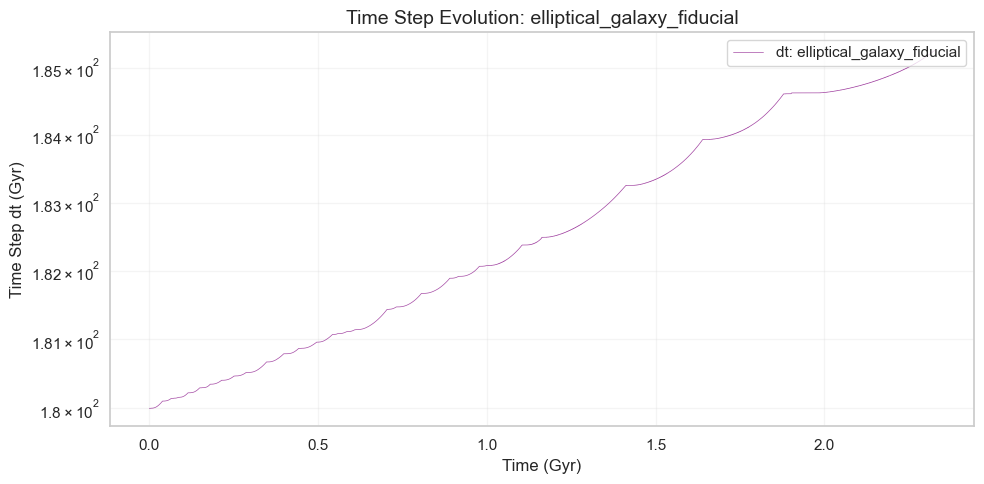

  - Galaxy: elliptical_galaxy_0dot1


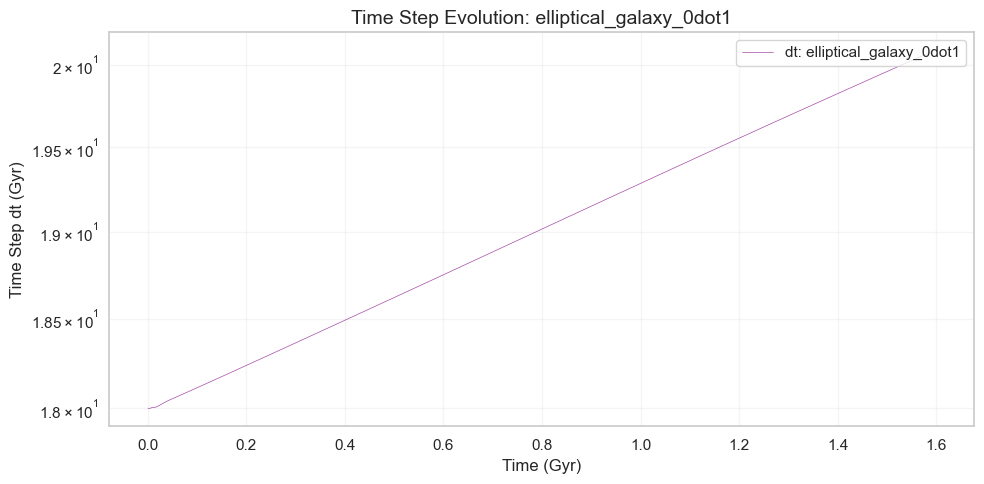

  - Galaxy: elliptical_galaxy_pgc


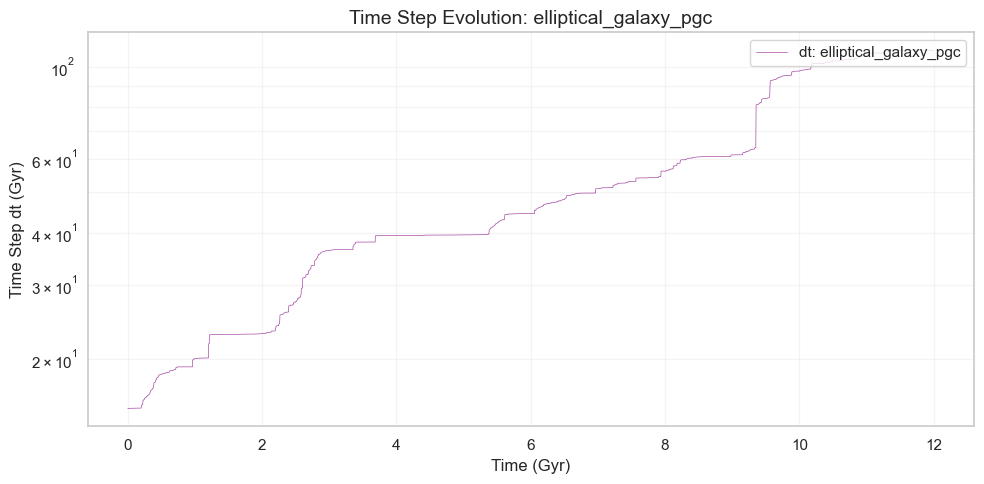

Processing Group Type: disk_galaxy
  - Galaxy: disk_galaxy_fiducial


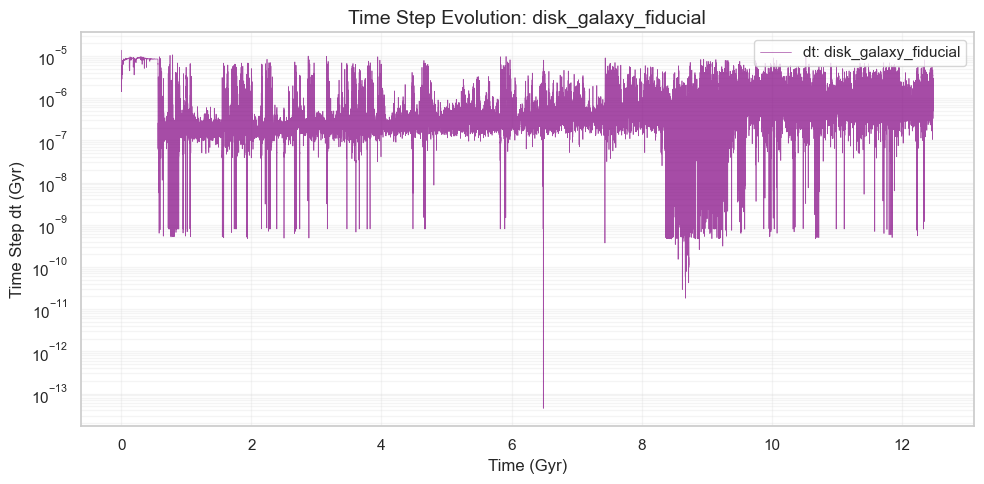

  - Galaxy: disk_galaxy_supplement


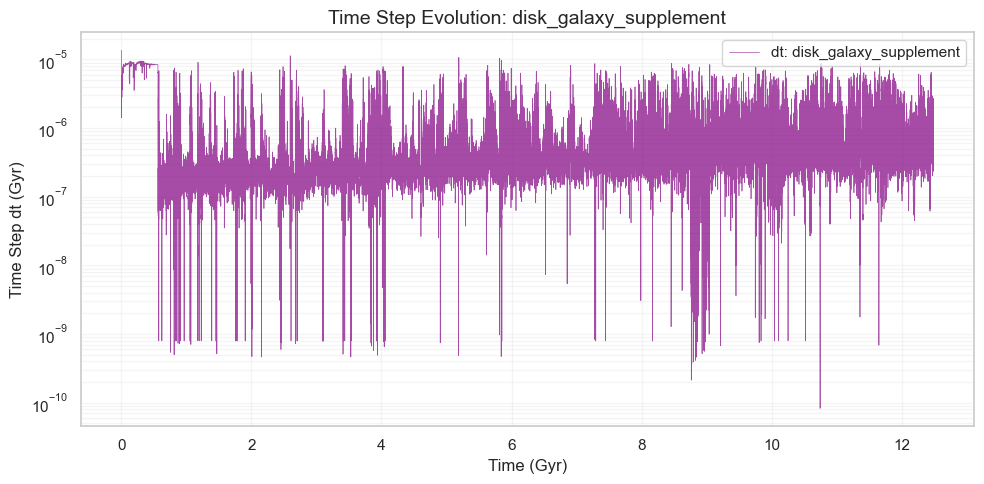

  - Galaxy: disk_galaxy_fiducial_4


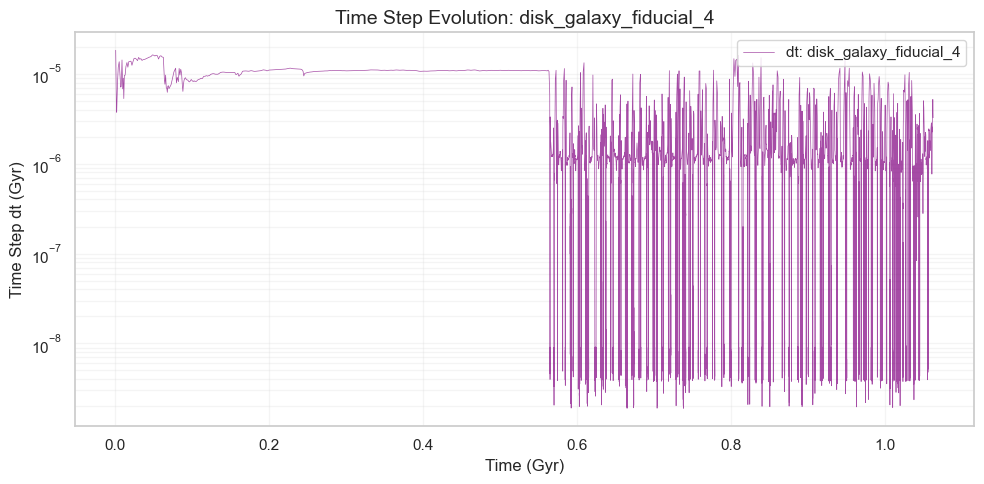

  - Galaxy: disk_galaxy_fiducial_7


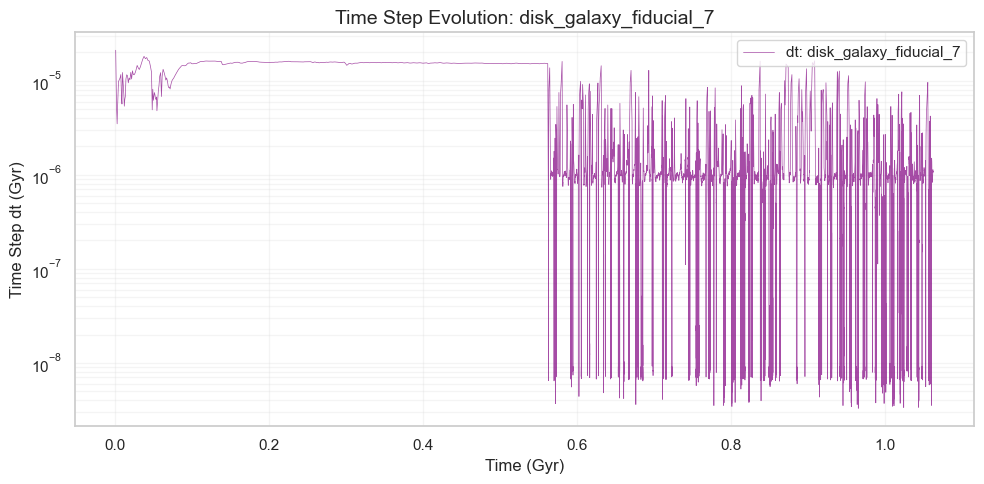

  - Galaxy: disk_galaxy_fiducial_10


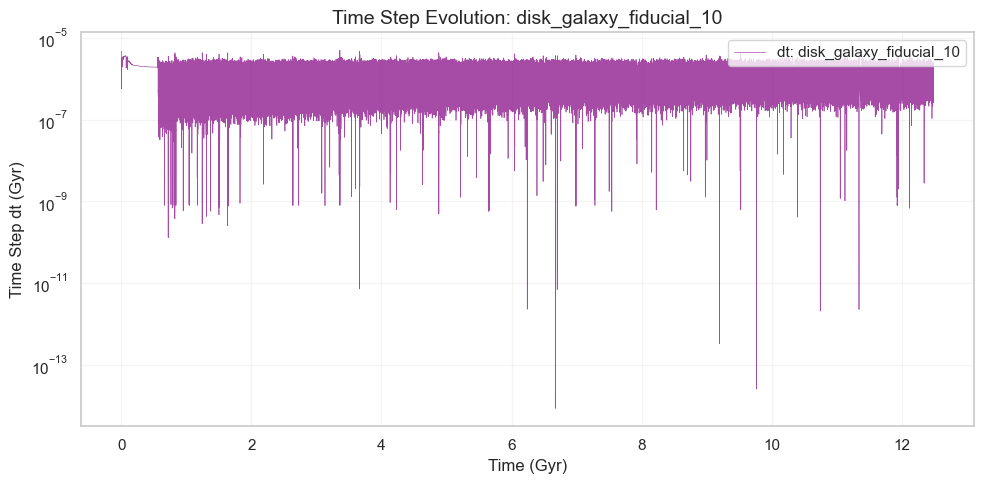

  - Galaxy: disk_galaxy_low


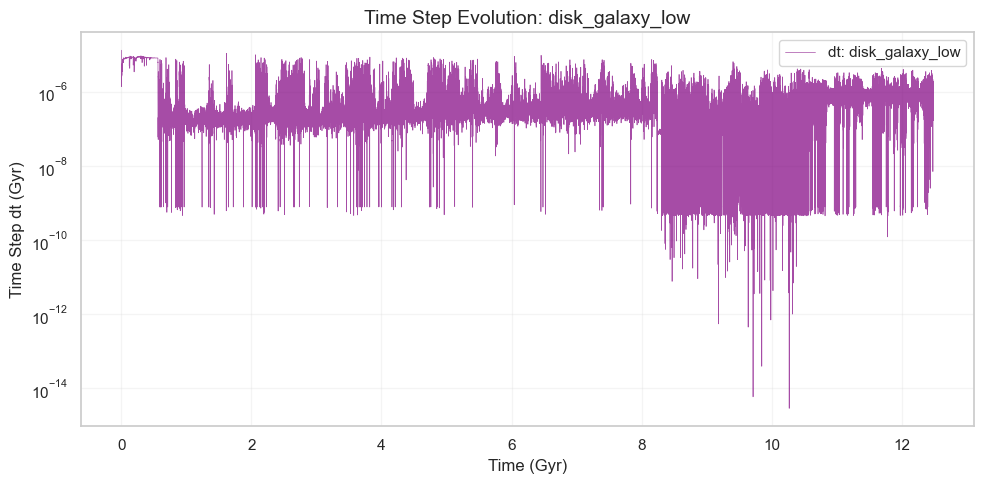

In [4]:
# ==========================================
# Part 3: Time Step (dt) Evolution Analysis
# ==========================================
# This section plots the evolution of the simulation time step (dt) over time.
# Useful for checking numerical stability or adaptive time-stepping behavior.

print("\n" + "="*50)
print("Starting Time Step (dt) Evolution Analysis (.parquet)")
print("="*50 + "\n")

# Iterate over all defined galaxy groups
for gal_type, gal_group in configs["RawDataConfig"].items():
    print(f"Processing Group Type: {gal_type}")
    
    for gal_nickname, gal_config in gal_group.items():
        gal_name = f"{gal_type}_{gal_nickname}"
        print(f"  - Galaxy: {gal_name}")
        
        # Define path to parquet (generated in Part 1)
        parquet_path = os.path.join(data_dir, f"{gal_name}.parquet")
        
        if not os.path.exists(parquet_path):
            print(f"    [Skip] Parquet file not found: {parquet_path}")
            continue
            
        try:
            # Load Data
            df = pd.read_parquet(parquet_path)
            
            # Check columns
            if "dt" not in df.columns or "time" not in df.columns:
                print(f"    [Warning] Missing 'dt' or 'time' column in {gal_name}")
                continue
                
            time = df["time"]
            dt = df["dt"]
            
            # Clean Data (ensure positive time)
            mask = time > 0
            valid_time = time[mask]
            valid_dt = dt[mask]
            
            if len(valid_time) == 0:
                print("    [Warning] No valid data points.")
                continue

            # Plot
            plt.figure(figsize=(10, 5))
            # dt often spans orders of magnitude, so log scale is usually preferred for Y
            plt.semilogy(valid_time, valid_dt, label=f"dt: {gal_name}", color='purple', alpha=0.7, linewidth=0.5)
            
            plt.xlabel("Time (Gyr)", fontsize=12)
            plt.ylabel("Time Step dt (Gyr)", fontsize=12)
            plt.title(f"Time Step Evolution: {gal_name}", fontsize=14)
            plt.legend(loc="upper right")
            plt.grid(True, which="both", ls="-", alpha=0.2)
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"    [Error] Failed to analyze dt for {gal_name}: {e}")
